In [ ]:
!pip install -q tensorflow

In [1]:
# Standard libraries for data handling, arrays, and plotting
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import json

# Metrics for evaluating RUL predictions
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.stats import wilcoxon

# TensorFlow/Keras for building the attention-augmented Bi-LSTM
import tensorflow as tf
from tensorflow.keras import Input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Layer, Bidirectional, LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.losses import Huber


In [2]:
# All artifacts from the baseline and Bi-LSTM notebooks live in this shared folder
BASE_PATH = '/content/drive/MyDrive/Sanjana/Maintenance_Log_Intelligence/dataset'

# Load the same preprocessed train/test data used in both previous notebooks
train_clean = pd.read_csv(f'{BASE_PATH}/train_processed.csv')
test_clean = pd.read_csv(f'{BASE_PATH}/test_processed.csv')
y_test = pd.read_csv(f'{BASE_PATH}/CMaps/RUL_FD001.txt', sep=r'\s+', header=None, names=['RUL'])

# Sensor columns retained after dropping constant sensors (from the baseline notebook)
remaining_sensors = [c for c in train_clean.columns if c.startswith('s_')]

# Load the previous Bi-LSTM's results so this notebook can compare against it directly
with open(f'{BASE_PATH}/lstm_metadata.json', 'r') as f:
    lstm_metadata = json.load(f)

lstm_rmse = lstm_metadata['results']['rmse']
lstm_mae = lstm_metadata['results']['mae']
lstm_score = lstm_metadata['results']['nasa_score']

print(f"Loaded previous Bi-LSTM results — RMSE: {lstm_rmse:.4f}, MAE: {lstm_mae:.4f}, NASA Score: {lstm_score:.4f}")

Loaded previous Bi-LSTM results — RMSE: 15.8175, MAE: 11.4981, NASA Score: 527.7340


In [3]:
# Sequence generation functions

WINDOW_LENGTH = 30  # same window length used in the Bi-LSTM notebook, kept identical for a fair comparison

def generate_train_sequences(df, sensor_cols, window_length):
    # Slides a window across each engine's full trajectory, stride 1
    # Label for each window = RUL at the window's last cycle
    X, y = [], []
    for unit in df['unit_nr'].unique():
        engine_data = df[df['unit_nr'] == unit].sort_values('time_cycles')
        sensor_values = engine_data[sensor_cols].values
        rul_values = engine_data['RUL'].values
        num_cycles = len(engine_data)
        if num_cycles < window_length:
            continue
        for start in range(num_cycles - window_length + 1):
            end = start + window_length
            X.append(sensor_values[start:end])
            y.append(rul_values[end - 1])
    return np.array(X), np.array(y)

def generate_test_sequences(df, sensor_cols, window_length):
    # Test set only needs the LAST window per engine — the point at which we predict RUL
    X = []
    for unit in df['unit_nr'].unique():
        engine_data = df[df['unit_nr'] == unit].sort_values('time_cycles')
        sensor_values = engine_data[sensor_cols].values
        if len(sensor_values) >= window_length:
            window = sensor_values[-window_length:]
        else:
            pad_count = window_length - len(sensor_values)
            padding = np.repeat(sensor_values[0:1], pad_count, axis=0)
            window = np.vstack([padding, sensor_values])
        X.append(window)
    return np.array(X)

In [4]:
# Recreate the engine-level train/validation split

# Same random_state and split ratio as the Bi-LSTM so the train/val engines are identical
np.random.seed(42)
all_units = train_clean['unit_nr'].unique()
np.random.shuffle(all_units)

val_size = int(0.15 * len(all_units))
val_units = set(all_units[:val_size])
train_units = set(all_units[val_size:])

train_mask = train_clean['unit_nr'].isin(train_units)
val_mask = train_clean['unit_nr'].isin(val_units)

X_train, y_train = generate_train_sequences(train_clean[train_mask], remaining_sensors, WINDOW_LENGTH)
X_val, y_val = generate_train_sequences(train_clean[val_mask], remaining_sensors, WINDOW_LENGTH)
X_test = generate_test_sequences(test_clean, remaining_sensors, WINDOW_LENGTH)
y_test_true = y_test['RUL'].values

print(f"X_train: {X_train.shape}, X_val: {X_val.shape}, X_test: {X_test.shape}")

X_train: (15104, 30, 14), X_val: (2627, 30, 14), X_test: (100, 30, 14)


In [5]:
# NASA asymmetric scoring function

def nasa_score(y_true, y_pred):
    # Penalizes overestimating RUL (dangerous: engine fails earlier than predicted)
    # more heavily than underestimating RUL (safe: just extra maintenance)
    d = y_pred - y_true
    score = np.where(d < 0, np.exp(-d/13) - 1, np.exp(d/10) - 1)
    return np.sum(score)

In [6]:
# Custom Bahdanau attention layer

class BahdanauAttention(Layer):
    # Implements: e(t) = w2^T * tanh(W1 * H(t))
    # followed by softmax normalization over all timesteps,
    # then a weighted sum of hidden states as the context vector.
    # This lets the model learn which of the 30 cycles matter most for the final prediction.
    def __init__(self, units, **kwargs):
        super().__init__(**kwargs)
        self.W1 = Dense(units)
        self.w2 = Dense(1)

    def call(self, hidden_states):
        score = self.w2(tf.nn.tanh(self.W1(hidden_states)))
        attention_weights = tf.nn.softmax(score, axis=1)
        context_vector = tf.reduce_sum(attention_weights * hidden_states, axis=1)
        return context_vector, attention_weights

In [7]:
# Build the attention-augmented model

n_features = len(remaining_sensors)

inputs = Input(shape=(WINDOW_LENGTH, n_features))
x = Bidirectional(LSTM(128, return_sequences=True))(inputs)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

# return_sequences=True here (unlike the plain Bi-LSTM) so attention can see every timestep's hidden state
x = Bidirectional(LSTM(64, return_sequences=True))(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

context_vector, attention_weights = BahdanauAttention(64, name='bahdanau_attention')(x)

x = Dense(32, activation='relu')(context_vector)
x = Dropout(0.2)(x)
output = Dense(1, activation='relu')(x)  # ReLU enforces non-negative RUL

attention_model = Model(inputs, output)
attention_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=Huber(delta=10.0),
    metrics=['mae']
)
attention_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 30, 14)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 30, 256)        │       146,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 30, 128)        │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 30, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bahdanau_attention              │ [(None, 128), (None,   │         8,321 │
│ (BahdanauAttention)             │ 30, 1)]                │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 324,802 (1.24 MB)

 Trainable params: 324,034 (1.24 MB)

 Non-trainable params: 768 (3.00 KB)

In [8]:
# Train the model
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)

history_attn = attention_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=128,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - loss: 229.6306 - mae: 27.3306 - val_loss: 747.2413 - val_mae: 79.6127 - learning_rate: 0.0010
Epoch 2/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 111.2598 - mae: 15.2388 - val_loss: 563.1689 - val_mae: 60.9539 - learning_rate: 0.0010
Epoch 3/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 102.8221 - mae: 14.3199 - val_loss: 186.7996 - val_mae: 23.1196 - learning_rate: 0.0010
Epoch 4/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 98.8543 - mae: 13.9046 - val_loss: 74.3032 - val_mae: 11.3542 - learning_rate: 0.0010
Epoch 5/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 94.2398 - mae: 13.4061 - val_loss: 56.5430 - val_mae: 9.1677 - learning_rate: 0.0010
Epoch 6/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 92.4126 - mae: 13.2133 - val_loss: 51.3552 - val_mae: 8.6619 - learning_rate: 0.0010
Epoch 7/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 94.5165 - mae: 13.4195 - val_loss: 53.3877 - 

In [9]:
# Evaluate and compare against the plain Bi-LSTM
attn_preds = attention_model.predict(X_test)[:, 0]

attn_rmse = np.sqrt(mean_squared_error(y_test_true, attn_preds))
attn_mae = mean_absolute_error(y_test_true, attn_preds)
attn_score = nasa_score(y_test_true, attn_preds)

comparison = pd.DataFrame([
    {'Model': 'Bi-LSTM', 'RMSE': lstm_rmse, 'MAE': lstm_mae, 'NASA_Score': lstm_score},
    {'Model': 'Bi-LSTM-Attention', 'RMSE': attn_rmse, 'MAE': attn_mae, 'NASA_Score': attn_score}
])

print(comparison)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 134ms/step
               Model       RMSE        MAE  NASA_Score
0            Bi-LSTM  15.817503  11.498095  527.733977
1  Bi-LSTM-Attention  15.452011  11.534740  497.902248


In [10]:
# Statistical significance test

# Need the plain Bi-LSTM's per-engine predictions to compare error distributions.
# If not saved previously, reload the plain Bi-LSTM model and regenerate predictions on X_test.
from tensorflow.keras.models import load_model
plain_lstm_model = load_model(f'{BASE_PATH}/bilstm_model.h5', compile=False)
lstm_preds = plain_lstm_model.predict(X_test).flatten()

lstm_abs_errors = np.abs(y_test_true - lstm_preds)
attn_abs_errors = np.abs(y_test_true - attn_preds)

stat, p_value = wilcoxon(lstm_abs_errors, attn_abs_errors)

print(f"Wilcoxon statistic: {stat:.4f}")
print(f"p-value: {p_value:.4f}")
print(f"Significant improvement at alpha=0.05: {p_value < 0.05}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 394ms/step
Wilcoxon statistic: 2360.0000
p-value: 0.5705
Significant improvement at alpha=0.05: False


In [11]:
# Error analysis by RUL range

error_df = pd.DataFrame({
    'actual_rul': y_test_true,
    'lstm_error': lstm_abs_errors,
    'attn_error': attn_abs_errors
})

# Bin engines by how close they are to failure, to see where each model struggles most
error_df['rul_bin'] = pd.cut(error_df['actual_rul'], bins=[0, 25, 50, 75, 100, 130],
                               labels=['0-25', '25-50', '50-75', '75-100', '100+'])

error_by_bin = error_df.groupby('rul_bin')[['lstm_error', 'attn_error']].mean()
print(error_by_bin)

         lstm_error  attn_error
rul_bin                        
0-25       2.120443    4.354309
25-50      8.167660    7.239966
50-75     19.736839   17.138766
75-100    17.924876   15.276563
100+       8.277400   10.129957


/tmp/ipykernel_2804/823140823.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  error_by_bin = error_df.groupby('rul_bin')[['lstm_error', 'attn_error']].mean()


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 868ms/step


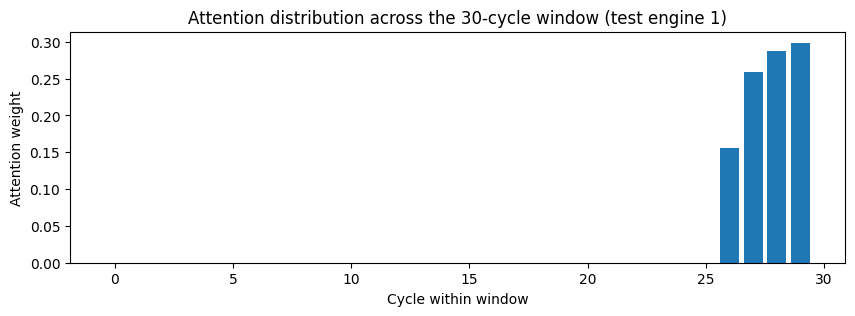

In [12]:
# Extract just the attention_weights output (second output of the BahdanauAttention layer)
attention_extractor = Model(attention_model.input, attention_model.get_layer('bahdanau_attention').output[1])
sample_weights = attention_extractor.predict(X_test[:1])[0, :, 0]

plt.figure(figsize=(10, 3))
plt.bar(range(WINDOW_LENGTH), sample_weights)
plt.xlabel('Cycle within window')
plt.ylabel('Attention weight')
plt.title('Attention distribution across the 30-cycle window (test engine 1)')
plt.show()

In [13]:
attention_model.save(f'{BASE_PATH}/bilstm_attention_model.h5')
comparison.to_csv(f'{BASE_PATH}/attention_model_comparison.csv', index=False)

metadata = {
    'window_length': WINDOW_LENGTH,
    'architecture': 'Bidirectional LSTM (128 -> 64) + Bahdanau Attention + Dense',
    'results': {'rmse': float(attn_rmse), 'mae': float(attn_mae), 'nasa_score': float(attn_score)},
    'wilcoxon_p_value': float(p_value)
}

with open(f'{BASE_PATH}/attention_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("Saved: bilstm_attention_model.h5, attention_model_comparison.csv, attention_metadata.json")

Saved: bilstm_attention_model.h5, attention_model_comparison.csv, attention_metadata.json
